In [32]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import time
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC


In [47]:
SEARCH_QUERY = "sony wireless headphones"
NUM_PAGES = 1
OUTPUT_FILE = "amazon_wireless_headphones.csv"

def clean_rating(text):
    if not text:
        return None
    match = re.search(r"\d+\.\d+", text)
    return float(match.group()) if match else None

options = Options()
options.add_argument("--headless=new")
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(options=options)
wait = WebDriverWait(driver, 15)

rows = []

try:
    for page in range(1, NUM_PAGES + 1):
        #url = f"https://www.amazon.com/s?k=wireless+headphones&rh=n%3A21514463011%2Cp_123%3A233043%257C264616%257C325772&dc&crid=37RAF0SVWP0ZZ&qid=1776023787&rnid=85457740011&sprefix=%2Caps%2C177&ref=sr_nr_p_123_4&ds=v1%3AaS7xNxv3ETbq0rBMp0a1QOxUuJUGO4XFffw2gLNIQOY"
        url = f"https://www.amazon.com/s?k={SEARCH_QUERY.replace(' ', '+')}&page={page}"
        driver.get(url)

        wait.until(
            EC.presence_of_all_elements_located(
                (By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]')
            )
        )

        time.sleep(2)
        product_cards = driver.find_elements(By.CSS_SELECTOR, 'div[data-component-type="s-search-result"]')

        for card in product_cards:
            title = None
            rating = None
            review_count = None
            price = None

            # TITLE
            try:
                title = card.find_element(By.CSS_SELECTOR, "h2 span").text.strip()
            except:
                pass

            # RATING - try several possible selectors
            rating_text = None
            selectors_to_try = [
                "span.a-icon-alt",
                "i span.a-icon-alt",
                '[aria-label*="out of 5 stars"]',
                '[aria-label*="stars"]'
            ]

            for sel in selectors_to_try:
                try:
                    el = card.find_element(By.CSS_SELECTOR, sel)
                    rating_text = el.text.strip() or el.get_attribute("aria-label")
                    if rating_text:
                        break
                except:
                    continue

            rating = clean_rating(rating_text)

            try:
                review_tag = card.find_element(
                    By.CSS_SELECTOR,
                    'span.a-size-mini.puis-normal-weight-text.s-underline-text'
                )
                
                review_text = review_tag.text.strip()

                review_text = review_text.replace("(", "").replace(")", "").lower()

                if "k" in review_text:
                    number = float(review_text.replace("k", ""))
                    review_count = int(number * 1000)
                else:
                    review_count = int(review_text.replace(",", ""))

            except:
                pass

            try:
                whole = card.find_element(By.CSS_SELECTOR, ".a-price-whole").text
                fraction = card.find_element(By.CSS_SELECTOR, ".a-price-fraction").text
                
                price = float(f"{whole}.{fraction}")

            except:
                pass
        

            if title:
                rows.append({
                    "title": title,
                    "rating": rating,
                    "number of reviews": review_count,
                    "Price": price,
                    "page": page,
                    "source": "Amazon"
                })

            

        time.sleep(2)

finally:
    driver.quit()

df = pd.DataFrame(rows)
df.to_csv(OUTPUT_FILE, index=False)
print(f"Saved {len(df)} rows to {OUTPUT_FILE}")


Saved 16 rows to amazon_wireless_headphones.csv


In [48]:
df = pd.read_csv("amazon_wireless_headphones.csv")
df.head()

,title,rating,number of reviews,Price,page,source
0,Sony,4.5,31200,38.0,1,Amazon
1,Sony,4.4,15000,NaN,1,Amazon
2,Sony,4.2,19200,248.0,1,Amazon
3,Sony,4.3,13700,28.0,1,Amazon
4,Sony,4.3,2500,428.0,1,Amazon


In [49]:
df.shape

(16, 6)

In [50]:
display(pd.DataFrame(df.dtypes.astype(str), columns=['dtype']).reset_index().rename(columns={'index':'column'}))

,column,dtype
0,title,object
1,rating,float64
2,number of reviews,int64
3,Price,float64
4,page,int64
5,source,object


<Axes: xlabel='rating', ylabel='Price'>

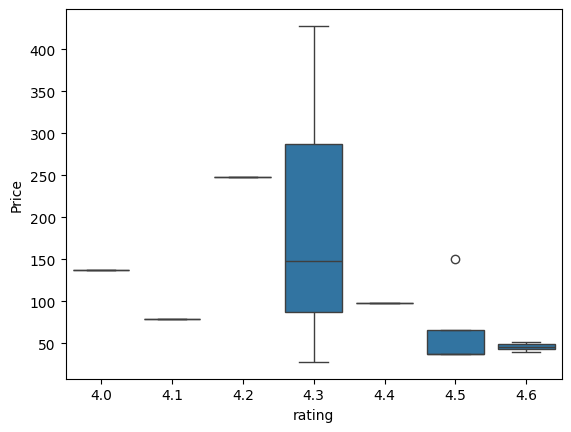

In [52]:
import seaborn as sns
sns.boxplot(x="rating", y="Price", data=df)